# Ceridwen photometry and spectroscopy fit

- Joint fit of COSMOS2015 photometry and the LEGA-C DR2 spectrum of one galaxy.

## Settings and priors

- The batch launcher sets target, manifest index, seed and result directory per galaxy.
- Every fit setting and prior is in the two dicts below; nothing else is configurable.
- String prior entries are resolved from the grid and the catalogue in the model cell.
- A parameter is sampled only when it has a `PRIORS` entry.

In [1]:
import os
import sys
from itertools import pairwise
from pathlib import Path

os.environ["JAX_ENABLE_X64"] = "1"

import astropy.units as u
from astropy.constants import c as C_LIGHT
import corner
import h5py
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.table import Table
from astropy.visualization import AsinhStretch, ImageNormalize, PercentileInterval
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from ceridwen.cosmology import age_gyr, flux_factor_maggies
from ceridwen.csp import CSPBasis_afe
from ceridwen.fit import load_result_h5
from ceridwen.likelihood import (
    DiagonalGaussianLikelihood,
    DiagonalNoiseModel,
    MultiObservationLikelihood,
    PolynomialCalibration,
)
from ceridwen.model import SedModel, logsfr_ratios_to_sfh
from ceridwen.observation import Photometry, Spectrum
from ceridwen.sampler import run_sampler
from ceridwen.sampler.nested import BlackJAXNestedSamplerAdapter
from ceridwen.sampler.priors import ClippedNormal, StudentT, Uniform
from ceridwen.ssps import SSPDataAfe, fetch_grid
from scipy.special import softmax
from scipy.stats import entropy
from specutils.utils.wcs_utils import air_to_vac

jax.config.update("jax_enable_x64", True)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "scripts"))
from per_galaxy_diagnostics import model_parameter_block  # noqa: E402
from spectral_figures import mark_absorption_features, spectral_tight_layout  # noqa: E402

TARGET_ID = "M14_38648"
MANIFEST_INDEX = 5
SEED = 20260835
RESULT_DIR = PROJECT_ROOT / "results/dr2-quiescent-new-defaults/38648-M14_38648"
QUICK = False
RESULT_DIR.mkdir(parents=True, exist_ok=True)

SETTINGS = {
    "photometry": "cosmos_total",  # Laigle+16 aperture-to-total, extinction and zero-point corrections
    "photometry_floor": 0.05,  # fractional error floor added in quadrature
    "emission_lines": [3726.0, 3728.8, 4861.3, 4958.9, 5006.8],  # rest A, masked +/- 1500 km/s
    "telluric_air": (7590.0, 7660.0),  # observed A, masked
    "sfh_lookback_gyr": [0.0, 0.03, 0.1, 0.3, 1.0, 3.0, 5.0],  # bin edges; the last edge is the universe age at z
    "calibration_order": 3,  # Chebyshev polynomial on the model spectrum, marginalised analytically
    "calibration_prior_sigma": 0.1,
    "zred_half_width": 0.1,  # zred prior: catalogue z +/- this
    "sigma_clip": 3.0,  # sigma_smooth prior: DR2 sigma +/- this many DR2 errors
    "sampler": {"num_live": 500, "num_inner_steps": 65, "num_delete": 100, "logZ_tol": -5.0},
    "sampler_quick": {"num_live": 16, "num_inner_steps": 2, "num_delete": 8, "logZ_tol": 1e4},
}
PRIORS = {
    "logmass": Uniform(low=8.0, high=13.0),
    "logsfr_ratios": StudentT(mean=0.0, scale=0.3, df=2.0),  # log10 SFR ratio of adjacent bins
    "Z": "Uniform over the grid",  # log10 iron abundance; [Fe/H] = Z + 1.7328283
    "afe": "Uniform over the grid",
    "diffuse_tau_kc": Uniform(low=0, high=2),
    "diffuse_dust_index": Uniform(low=-1.0, high=0.4),  # Kriek & Conroy slope
    "log_f_calib": Uniform(low=np.log(0.01), high=np.log(0.10)),  # fractional noise floor on the spectrum
    "spectrum_scaling": ClippedNormal(mean=1.0, sigma=0.3, low=0.2, high=3.0),
}
C_KMS = float(C_LIGHT.to_value(u.km / u.s))

## Data and target

- Passive LEGA-C DR2 sample: quality flags, NUVrJ, weak [OII] and [OIII], clean twelve-band photometry.
- Target row, its public one-dimensional spectrum, catalogue redshift and dispersion.
- HST ACS F814W cutout with the COSMOS2015 3 arcsec aperture.

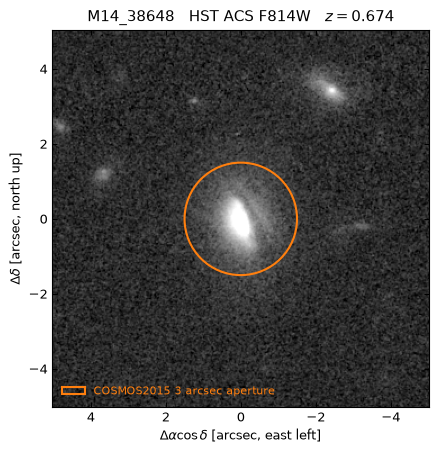

In [2]:
legac = Table.read(PROJECT_ROOT / "data/raw/legac_dr2/legaCdr2.fits.gz").to_pandas()
for text_column in ["SPECT_ID", "Filename"]:
    legac[text_column] = legac[text_column].map(
        lambda value: value.decode() if isinstance(value, bytes) else value
    )
phot = Table.read(
    PROJECT_ROOT / "data/raw/cosmos2015/cosmos2015_legac_dr2_photometry_1arcsec.fits"
).to_pandas().set_index("LEGAC_INDEX")
BANDS = {  # filter: (label, COSMOS2015 3-arcsec flux column)
    "cfht_megacam_us_9301": ("u*", "Fuap3"),
    "subaru_suprimecam_B": ("B", "FBap3"),
    "subaru_suprimecam_V": ("V", "FVap3"),
    "subaru_suprimecam_rp": ("r+", "Frap3"),
    "subaru_suprimecam_ip": ("i+", "Fipap3"),
    "subaru_suprimecam_zp": ("z+", "Fzppap3"),
    "vista_vircam_Y": ("Y", "FYap3"),
    "vista_vircam_J": ("J", "FJap3"),
    "vista_vircam_H": ("H", "FHap3"),
    "vista_vircam_Ks": ("Ks", "FKsap3"),
    "spitzer_irac_ch1": ("3.6 um", "F3.6um"),
    "spitzer_irac_ch2": ("4.5 um", "F4.5um"),
}
FILTER_NAMES = list(BANDS)
FILTER_LABELS = [label for label, _ in BANDS.values()]
FLUX_COLUMNS = [column for _, column in BANDS.values()]
ERROR_COLUMNS = [f"e_{column}" for column in FLUX_COLUMNS]
parent = legac.join(
    phot[["Area", "Sat", "Cfl", "Flag", "NUVMag", "RMag", "JMag", *FLUX_COLUMNS, *ERROR_COLUMNS]],
    how="inner",
)

quality = (
    (parent["f_use"] == 1)
    & (parent["f_ppxf"] == 0)
    & (parent["f_z"] == 0)
    & (parent["f_int"] == 0)
    & (parent["SN"] > 0)
    & (parent["z"] >= 0.6)
    & (parent["z"] < 1.0)
    & (parent[["NUVMag", "RMag", "JMag"]] > -40).all(axis=1)
)
parent = parent[quality]
nuv_r = parent["NUVMag"] - parent["RMag"]
r_j = parent["RMag"] - parent["JMag"]
photometric_passive = parent[(nuv_r > 3 * r_j + 1) & (nuv_r > 3.1)]
oii_ew = photometric_passive["OII_3727_EW"]
weak_oii = photometric_passive[(oii_ew > -5) | oii_ew.isna()]
oii_significance = (weak_oii["OII_3727_EW"] / weak_oii["OII_3727_EW_err"]).abs()
oiii_significance = (weak_oii["OIII_5007_EW"] / weak_oii["OIII_5007_EW_err"]).abs()
bona_fide_passive = weak_oii[~((oii_significance >= 3) | (oiii_significance >= 3))]
clean_photometry = (
    (bona_fide_passive["Area"] == 0)
    & (bona_fide_passive["Sat"] == 0)
    & (bona_fide_passive["Cfl"] == 1)
    & (bona_fide_passive["Flag"] == 0)
)
selected_passive = (
    bona_fide_passive[clean_photometry]
    .sort_values(["SN", "SPECT_ID"], ascending=[False, True])
    .drop_duplicates("OBJECT", keep="first")
)

galaxy = selected_passive[selected_passive["SPECT_ID"] == TARGET_ID].iloc[0]
OBJECT_ID = int(galaxy["OBJECT"])
with fits.open(PROJECT_ROOT / "data/raw/legac_dr2/sp" / galaxy["Filename"]) as hdulist:
    spectrum_table = hdulist[1].data
    instrument_fwhm_resolution = float(hdulist[0].header["SPEC_RES"])
wave_air, flux_dr2, error_dr2, quality_flag = (
    spectrum_table[column][0] for column in ("WAVE", "FLUX", "ERR", "QUAL")
)
good_pixel = (quality_flag == 0) & (error_dr2 > 0) & np.isfinite(flux_dr2)
z_catalog = float(galaxy["z"])
sigma_star = float(galaxy["SIGMA_STARS_PRIME"])
sigma_star_err = float(galaxy["SIGMA_STARS_PRIME_err"])
has_4000a_coverage = bool(
    wave_air[good_pixel].min() < 4000 * (1 + z_catalog) < wave_air[good_pixel].max()
)

# HST ACS F814W cutout, north up and east left, with the COSMOS2015 3-arcsec aperture.
APERTURE_DIAMETER_ARCSEC = 3.0
with fits.open(PROJECT_ROOT / f"data/raw/hst_f814w/{TARGET_ID}.fits") as cutout_hdulist:
    cutout_image = np.asarray(cutout_hdulist[0].data, dtype=float)
    cutout_wcs = WCS(cutout_hdulist[0].header)
scale_ra, scale_dec = proj_plane_pixel_scales(cutout_wcs) * 3600  # arcsec/pixel
column_target, row_target = cutout_wcs.all_world2pix(
    float(galaxy["RAJ2000"]), float(galaxy["DECJ2000"]), 0
)
rows, columns = cutout_image.shape
cutout_extent = (  # offsets from the catalogue position; east is +x, so on the left
    (column_target + 0.5) * scale_ra,
    -(columns - 0.5 - column_target) * scale_ra,
    -(row_target + 0.5) * scale_dec,
    (rows - 0.5 - row_target) * scale_dec,
)
fig, ax = plt.subplots(figsize=(4.6, 4.6))
ax.imshow(
    cutout_image,
    origin="lower",
    extent=cutout_extent,
    cmap="gray",
    norm=ImageNormalize(cutout_image, interval=PercentileInterval(99.5), stretch=AsinhStretch()),
)
ax.add_patch(
    plt.Circle(
        (0, 0),
        APERTURE_DIAMETER_ARCSEC / 2,
        fill=False,
        color="tab:orange",
        lw=1.5,
        label=f"COSMOS2015 {APERTURE_DIAMETER_ARCSEC:.0f} arcsec aperture",
    )
)
ax.legend(loc="lower left", frameon=False, labelcolor="tab:orange", fontsize=8)
ax.set(
    xlabel=r"$\Delta\alpha\cos\delta$ [arcsec, east left]",
    ylabel=r"$\Delta\delta$ [arcsec, north up]",
    title=f"{TARGET_ID}   HST ACS F814W   $z={z_catalog:.3f}$",
)
plt.tight_layout()
plt.show()

## Observations

- Twelve COSMOS2015 bands to maggies with the Laigle+16 total corrections and the error floor.
- Spectrum to vacuum wavelength and F_nu; emission lines and the telluric band masked.
- Redshift and dispersion are sampled by the spectrum when `PRIORS` lists them.

In [3]:
UJY_TO_MAGGIES = 1e-6 / 3631.0
CGS_FNU_PER_MAGGIE = 3631e-23
phot_flux = galaxy[FLUX_COLUMNS].to_numpy(dtype=float) * UJY_TO_MAGGIES
phot_error_stat = galaxy[ERROR_COLUMNS].to_numpy(dtype=float) * UJY_TO_MAGGIES
# Laigle et al. (2016) total SED: per-object aperture-to-total offset (optical/NIR only;
# IRAC is already total), Galactic extinction and the Table 3 zero-point offsets, in mag.
COSMOS2015_SF = np.array(
    [0.010, 0.146, -0.117, -0.012, 0.020, -0.084, 0.001, 0.017, 0.055, -0.001, -0.025, -0.005]
)
COSMOS2015_EXTINCTION = np.array(
    [4.660, 4.020, 3.117, 2.660, 1.991, 1.461, 1.211, 0.871, 0.563, 0.364, 0.162, 0.111]
)
apertures = Table.read(
    PROJECT_ROOT / "data/raw/cosmos2015/cosmos2015_legac_dr2_apertures_1arcsec.fits"
)
aperture_row = apertures[np.asarray(apertures["LEGAC_INDEX"]) == int(galaxy.name)]
total_correction_mag = (
    float(aperture_row["Offset"][0]) * np.array([1.0] * 10 + [0.0, 0.0])
    - float(aperture_row["E(B-V)"][0]) * COSMOS2015_EXTINCTION
    - COSMOS2015_SF
)
total_scale = 10.0 ** (-0.4 * total_correction_mag)
phot_flux = phot_flux * total_scale
phot_uncertainty = np.hypot(
    phot_error_stat * total_scale, SETTINGS["photometry_floor"] * np.abs(phot_flux)
)
phot_fit_mask = np.ones(len(FILTER_NAMES), dtype=bool)
phot_obs = Photometry(
    filters=FILTER_NAMES,
    flux=phot_flux,
    uncertainty=phot_uncertainty,
    mask=phot_fit_mask,
    name="photometry",
)

filter_wave_eff = np.asarray(phot_obs.wave_eff)
filter_blue_edge = np.array(
    [float(filter_curve.blue_edge) for filter_curve in phot_obs.filterset.filters]
)
filter_red_edge = np.array(
    [float(filter_curve.red_edge) for filter_curve in phot_obs.filterset.filters]
)
filter_wave_xerr = np.vstack(
    [filter_wave_eff - filter_blue_edge, filter_red_edge - filter_wave_eff]
)
filter_colors = plt.cm.tab20(np.linspace(0, 1, len(FILTER_NAMES)))


def mark_filter_ranges(ax, show_labels=True):
    x_limits = ax.get_xlim()
    for index, (label, blue, red, effective, color) in enumerate(
        zip(FILTER_LABELS, filter_blue_edge, filter_red_edge, filter_wave_eff, filter_colors, strict=True)
    ):
        visible_blue = max(blue, x_limits[0])
        visible_red = min(red, x_limits[1])
        if visible_blue >= visible_red:
            continue
        ax.axvspan(
            visible_blue, visible_red, facecolor=color, edgecolor=color, alpha=0.18, linewidth=1.0, zorder=0
        )
        if show_labels:
            label_wave = (
                effective if visible_blue <= effective <= visible_red else 0.5 * (visible_blue + visible_red)
            )
            ax.text(
                label_wave,
                0.98 - 0.07 * (index % 2),
                label,
                color="0.15",
                fontsize=8,
                fontweight="semibold",
                ha="center",
                va="top",
                transform=ax.get_xaxis_transform(),
                clip_on=True,
            )
    ax.set_xlim(x_limits)


def mark_spectral_range(ax, show_label=False):
    fitted_wave = spectrum_wave[spectrum_mask]
    ax.axvspan(
        fitted_wave.min(), fitted_wave.max(), facecolor="tab:purple", edgecolor="tab:purple",
        alpha=0.12, linewidth=0.0, linestyle="--", zorder=-1,
    )
    for boundary in (fitted_wave.min(), fitted_wave.max()):
        ax.axvline(boundary, color="tab:purple", alpha=0.95, linewidth=1.5, linestyle="--", zorder=1)
    if show_label:
        ax.plot([], [], color="tab:purple", linewidth=1.5, linestyle="--", label="LEGA-C spectroscopic data range")


DR2_FLUX_UNIT = 1e-19 * u.erg / u.s / u.cm**2 / u.AA


def flam_to_fnu_cgs(values, wavelength):
    return (values * DR2_FLUX_UNIT).to_value(
        u.erg / u.s / u.cm**2 / u.Hz, equivalencies=u.spectral_density(wavelength * u.AA)
    )


wave_vacuum = air_to_vac(wave_air * u.AA).to_value(u.AA)
native_flux = flam_to_fnu_cgs(flux_dr2, wave_vacuum)
native_uncertainty = flam_to_fnu_cgs(error_dr2, wave_vacuum)
native_valid = (
    good_pixel & np.isfinite(native_flux) & np.isfinite(native_uncertainty) & (native_uncertainty > 0)
)
spectrum_wave = wave_vacuum
spectrum_flux = np.nan_to_num(native_flux, nan=0.0)
spectrum_uncertainty = np.where(native_valid, native_uncertainty, 1.0)
spectrum_obs = Spectrum(
    wavelength=spectrum_wave,
    flux=spectrum_flux,
    uncertainty=spectrum_uncertainty,
    mask=native_valid,
    resolution=instrument_fwhm_resolution,
    smoothtype="R",
    res_convention="fwhm",
    sigma_losvd=sigma_star,
    fit_sigma_smooth="sigma_smooth" in PRIORS,
    free_z="zred" in PRIORS,
    name="spectrum",
)
spectrum_obs.mask_lines(SETTINGS["emission_lines"], dv=1500.0, zred=z_catalog)
spectrum_obs.mask_wavelength_range(
    *air_to_vac(np.array(SETTINGS["telluric_air"]) * u.AA).to_value(u.AA)
)
spectrum_mask = np.asarray(spectrum_obs.mask)

## Model

- Alpha-enhanced C3K high-resolution grid; step SFH on the lookback bins up to the universe age at z.
- `logsfr_ratios` map to a unit-mass SFH; `logmass` scales it.
- Priors from `PRIORS`; Z and afe span the grid, zred and sigma_smooth centre on the catalogue.
- Initial `logmass` shifted so the first model matches the photometry.

In [4]:
ssp = SSPDataAfe.load(fetch_grid("amist_c3k_hr_krou_afe"))
universe_age = float(age_gyr(z_catalog))
lookback_template = np.array([*SETTINGS["sfh_lookback_gyr"], universe_age])
N_RATIOS = len(lookback_template) - 1

joint_csp = CSPBasis_afe(
    ssp,
    theta={
        "lookback_time": jnp.asarray(lookback_template),
        "sfh": jnp.ones(len(lookback_template)),
        "Z": jnp.array([-1.85]),
        "afe": jnp.array([0.2]),
        "diffuse_tau_kc": jnp.array([0.1]),
        "diffuse_dust_index": jnp.array([-0.7]),
    },
    zh_const=True,
    sfh_interp="step",
    add_dust=False,
    add_diffuse_dust=True,
    add_dust_emission=False,
    add_igm=False,
    sigma_losvd_kms=0.0,
    track_zred_age=False,
    verbose=False,
)


def sfh_from_ratios(free_theta):
    return logsfr_ratios_to_sfh(
        free_theta["logsfr_ratios"], sfh_times_yr=np.asarray(joint_csp.sfh_times)
    )


joint_priors = {name: prior for name, prior in PRIORS.items() if not isinstance(prior, str)}
joint_priors["Z"] = Uniform(
    low=float(ssp.ssp_lgmet.min()) + 1e-4, high=float(ssp.ssp_lgmet.max()) - 1e-4
)
joint_priors["afe"] = Uniform(low=float(ssp.ssp_afe.min()), high=float(ssp.ssp_afe.max()))
if "zred" in PRIORS:
    joint_priors["zred"] = Uniform(
        low=z_catalog - SETTINGS["zred_half_width"], high=z_catalog + SETTINGS["zred_half_width"]
    )
if "sigma_smooth" in PRIORS:
    joint_priors["sigma_smooth"] = ClippedNormal(
        mean=sigma_star,
        sigma=sigma_star_err,
        low=sigma_star - SETTINGS["sigma_clip"] * sigma_star_err,
        high=sigma_star + SETTINGS["sigma_clip"] * sigma_star_err,
    )
joint_bounds = {
    name: tuple(float(edge) for edge in prior.bounds)
    for name, prior in joint_priors.items()
    if name != "logsfr_ratios"
}
joint_bounds["logsfr_ratios"] = (-3.0, 3.0)
joint_initial = {
    "logsfr_ratios": jnp.zeros(N_RATIOS),
    "logmass": jnp.array([11.0]),
    "diffuse_dust_index": jnp.array([-0.7]),
    "log_f_calib": jnp.array([np.log(0.03)]),
    "spectrum_scaling": jnp.array([1.0]),
}
if "zred" in PRIORS:
    joint_initial["zred"] = jnp.array([z_catalog])
if "sigma_smooth" in PRIORS:
    joint_initial["sigma_smooth"] = jnp.array([sigma_star])
joint_model = SedModel(
    joint_csp,
    observations=[phot_obs, spectrum_obs],
    priors=joint_priors,
    transforms={"sfh": sfh_from_ratios},
    free_param_init=joint_initial,
    zred=z_catalog,
)
initial_photometry = np.asarray(joint_model.predict(joint_model.theta_init)["photometry"])
joint_model.theta_init["logmass"] = joint_model.theta_init["logmass"] + np.median(
    np.log10(phot_flux / initial_photometry)
)
_ = joint_csp.check_param_ranges(joint_model.apply_transforms(joint_model.theta_init))

Using only diffuse dust attenuation.
Initializing DiffuseDust model...
Dust initialization complete.
Spectrum model: dust attenuation only (alpha-enhanced, no nebular)


## Fit

- Chebyshev calibration polynomial on the model spectrum, coefficients integrated out at every call.
- Parameter block: the resolved model, stored in both result files.
- BlackJAX nested sampling; per-iteration progress goes to `ns_progress.jsonl`.
- Posterior reloaded from the stored fit; the sampler is not re-run.

In [5]:
joint_settings = SETTINGS["sampler_quick" if QUICK else "sampler"]
joint_adapter = BlackJAXNestedSamplerAdapter(
    priors=joint_model.priors,
    **joint_settings,
    checkpoint_interval_s=1200.0,
    checkpoint_dir=str(RESULT_DIR),
    verbose=False,
    progress_path=str(RESULT_DIR / "ns_progress.jsonl"),
)
calibration_polynomial = PolynomialCalibration.from_spectrum(
    spectrum_obs,
    order=SETTINGS["calibration_order"],
    fit_constant=False,
    prior_sigma=SETTINGS["calibration_prior_sigma"],
    marginalize=True,
)
joint_likelihood = MultiObservationLikelihood(
    keys=("photometry", "spectrum"),
    likelihoods=(
        DiagonalGaussianLikelihood(),
        DiagonalGaussianLikelihood(
            noise_model=DiagonalNoiseModel(use_fractional=True),
            calibration=calibration_polynomial,
        ),
    ),
)
model_parameter_block_text = model_parameter_block(
    joint_model, ssp, joint_likelihood, joint_settings, SEED
)
print(model_parameter_block_text)

joint_result = load_result_h5(RESULT_DIR / "ceridwen_result.h5")
print(joint_result.summary())

MODEL PARAMETERS (generated from the SedModel object)
Stellar population grid
  library: C3K v2.3 high-res (c3k_hr, vt=10 km/s); isochrones: MIST v2.5 (aMIST, alpha-variable); IMF: imf_type=2 (Kroupa (2001)); schema 2.1
  grid axes: [alpha/Fe] [-0.2, 0, 0.2, 0.4, 0.6]; [Fe/H] 13 nodes [-2.500, 0.500] (grid Z + 1.7328283); log10(age/Gyr) 107 nodes; wavelength 10992 pts [100, 99595855] A
Star-formation history
  form: piecewise-constant SFR ('step' interpolation) on 7 lookback bins; metallicity history: constant Z
  bin edges (lookback, Gyr): [0, 0.03, 0.1, 0.3, 1, 3, 5, 7.447]  (last edge = universe age at z)
  free parameters: logsfr_ratios[7] = log10(SFR_i / SFR_i+1), transform 'sfh_from_ratios' -> unit-mass SFH (integral 1 Msun); logmass scales the total formed mass
Free parameters and priors
  Z: shape (1,); prior Uniform(-4.233, -1.233); init [-1.85]
  afe: shape (1,); prior Uniform(-0.2, 0.6); init [0.2]
  diffuse_dust_index: shape (1,); prior Uniform(-1, 0.4); init [-0.7]
  diffu

## Sampling diagnostics

- KL(posterior || uniform prior) per parameter from the nested-sampling weights, 30 bins over the bounds.
- Effective sample size of the weights; equal-weight resample of 2000 rows for everything below.

In [6]:
def diagnostic_table(result, model, bounds):
    weights = softmax(np.asarray(result.log_weights))
    rows = []
    for name, parameter_template in model.theta_init.items():
        size = int(np.size(parameter_template))
        samples = np.asarray(result.samples[name]).reshape(len(weights), size)
        for component in range(size):
            counts, _ = np.histogram(samples[:, component], bins=30, range=bounds[name], weights=weights)
            probabilities = (counts + 1e-12) / np.sum(counts + 1e-12)
            rows.append(
                {
                    "parameter": name if size == 1 else f"{name}[{component}]",
                    "KL posterior||prior": entropy(probabilities, np.full(30, 1 / 30)),
                }
            )
    return pd.DataFrame(rows), weights


def equal_weight_posterior(result, weights, count, seed):
    rng = np.random.default_rng(seed)
    indices = rng.choice(len(weights), size=count, replace=True, p=weights)
    return {name: np.asarray(values)[indices] for name, values in result.samples.items()}


joint_diagnostics, joint_weights = diagnostic_table(joint_result, joint_model, joint_bounds)
display(joint_diagnostics)
joint_weight_ess = 1.0 / np.sum(joint_weights**2)
joint_diagnostics_passed = bool(
    np.isfinite(joint_result.log_evidence)
    and np.isfinite(joint_result.log_evidence_err)
    and joint_weight_ess >= 200
)
joint_status = "diagnostics passed" if joint_diagnostics_passed and not QUICK else "exploratory"
joint_posterior = equal_weight_posterior(joint_result, joint_weights, count=2000, seed=SEED + 1)
print(f"ln Z: {joint_result.log_evidence:.3f} +/- {joint_result.log_evidence_err:.3f}")
print(f"posterior-weight ESS: {joint_weight_ess:.1f}")
print(f"likelihood calls: {joint_result.n_likelihood_calls}")
print(f"status: {joint_status}")

,parameter,KL posterior||prior
0,Z,2.733134
1,afe,2.097846
2,diffuse_tau_kc,2.333753
3,diffuse_dust_index,1.674408
4,logsfr_ratios[0],1.371923
5,logsfr_ratios[1],1.236843
6,logsfr_ratios[2],1.359125
7,logsfr_ratios[3],1.268027
8,logsfr_ratios[4],1.753833
9,logsfr_ratios[5],1.509628


ln Z: 232882.297 +/- 0.398
posterior-weight ESS: 5208.2
likelihood calls: 9342499
status: diagnostics passed


## Output fit

- 200 evenly spaced posterior rows through the model; one calibration-coefficient draw per row.
- Photometry with the median continuum and pulls; spectrum with the 16-84 band and pulls.
- Pulls use the sampled fractional noise floor added to the pixel errors.

findfont: Failed to find font weight semibold, now using 700.


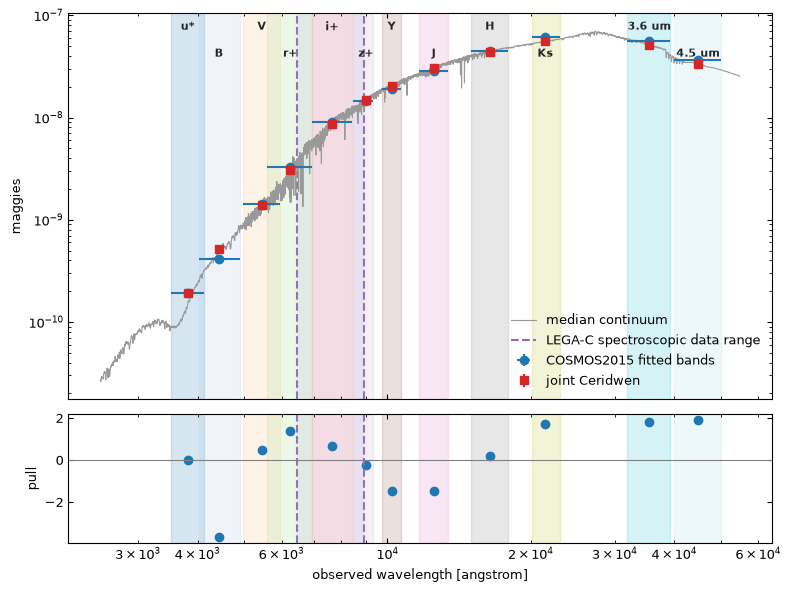

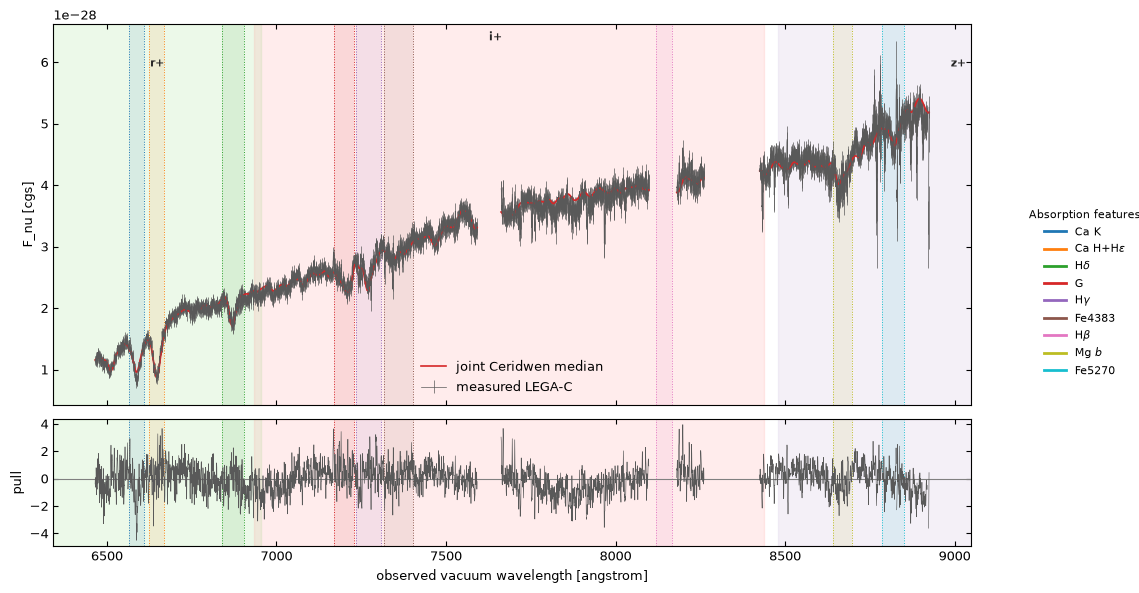

photometry chi2/datum: 2.52
spectrum chi2/bin: 1.05
joint chi2/datum: 1.06
sampled calibration floor: 2.80%


In [7]:
def posterior_batch(samples, model, count):
    total = len(next(iter(samples.values())))
    indices = np.linspace(0, total - 1, min(count, total), dtype=int)
    batch = {}
    for name, parameter_template in model.theta_init.items():
        values = np.asarray(samples[name])[indices]
        if np.shape(parameter_template) == (1,) and values.ndim == 1:
            values = values[:, None]
        batch[name] = jnp.asarray(values)
    return batch


predictive_batch = posterior_batch(joint_posterior, joint_model, 200)
joint_predictions = joint_model.predict_vmap(predictive_batch)
phot_predictions = np.asarray(joint_predictions["photometry"])
spectrum_predictions = np.asarray(joint_predictions["spectrum"])
# Per draw: the noise model's sigma at the uncalibrated model, then one coefficient
# draw from N(a_hat, N^-1); P(lambda) multiplies the prediction.
predictive_sigma = np.hypot(
    spectrum_uncertainty[None, :],
    np.exp(np.asarray(predictive_batch["log_f_calib"]).reshape(-1, 1)) * np.abs(spectrum_predictions),
)
calibration_coefficients, calibration_vectors = (
    np.asarray(value)
    for value in calibration_polynomial.posterior_draws(
        spectrum_flux, spectrum_predictions, predictive_sigma, spectrum_mask, jax.random.PRNGKey(SEED + 2)
    )
)
spectrum_predictions = spectrum_predictions * calibration_vectors
phot_q16, phot_q50, phot_q84 = np.percentile(phot_predictions, [16, 50, 84], axis=0)
spec_q16, spec_q50, spec_q84 = np.percentile(spectrum_predictions, [16, 50, 84], axis=0)

median_theta = {
    name: jnp.atleast_1d(np.median(np.asarray(values), axis=0)) for name, values in joint_posterior.items()
}
continuum = (
    np.asarray(joint_csp.get_spectrum(joint_model.apply_transforms(median_theta)))
    * 10 ** float(median_theta["logmass"][0])
    * float(flux_factor_maggies(z_catalog))
    / CGS_FNU_PER_MAGGIE
)
continuum_wave = np.asarray(joint_csp.wave) * (1 + z_catalog)
continuum_mask = (continuum_wave > 2500) & (continuum_wave < 55000)

fig, axes = plt.subplots(2, 1, figsize=(8, 6), gridspec_kw={"height_ratios": [3, 1]}, sharex=True)
axes[0].plot(
    continuum_wave[continuum_mask], continuum[continuum_mask], color="0.6", lw=0.8, label="median continuum"
)
axes[0].errorbar(
    filter_wave_eff, phot_flux, xerr=filter_wave_xerr, yerr=phot_uncertainty,
    fmt="o", color="tab:blue", label="COSMOS2015 fitted bands",
)
axes[0].errorbar(
    filter_wave_eff, phot_q50, yerr=[phot_q50 - phot_q16, phot_q84 - phot_q50],
    fmt="s", color="tab:red", label="joint Ceridwen",
)
axes[0].set(xscale="log", yscale="log", ylabel="maggies")
mark_filter_ranges(axes[0])
mark_spectral_range(axes[0], show_label=True)
axes[0].legend(frameon=False)
axes[1].axhline(0, color="0.5", lw=0.8)
axes[1].scatter(filter_wave_eff, (phot_flux - phot_q50) / phot_uncertainty, color="tab:blue")
mark_filter_ranges(axes[1], show_labels=False)
mark_spectral_range(axes[1])
axes[1].set(xscale="log", xlabel="observed wavelength [angstrom]", ylabel="pull")
spectral_tight_layout()
plt.show()

calibration_fraction = float(np.exp(np.median(np.asarray(joint_posterior["log_f_calib"]))))
effective_spec_uncertainty = np.hypot(spectrum_uncertainty, calibration_fraction * np.abs(spec_q50))
spectrum_plot_pull = np.where(
    spectrum_mask, (spectrum_flux - spec_q50) / effective_spec_uncertainty, np.nan
)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), gridspec_kw={"height_ratios": [3, 1]}, sharex=True)
axes[0].errorbar(
    spectrum_wave,
    np.where(spectrum_mask, spectrum_flux, np.nan),
    yerr=np.where(spectrum_mask, effective_spec_uncertainty, np.nan),
    fmt="-", lw=0.5, color="0.35", label="measured LEGA-C",
)
axes[0].plot(
    spectrum_wave, np.where(spectrum_mask, spec_q50, np.nan), color="tab:red", lw=1.2, label="joint Ceridwen median"
)
axes[0].fill_between(
    spectrum_wave,
    np.where(spectrum_mask, spec_q16, np.nan),
    np.where(spectrum_mask, spec_q84, np.nan),
    color="tab:red", alpha=0.25,
)
axes[0].set(ylabel="F_nu [cgs]")
axes[0].legend(frameon=False)
axes[1].axhline(0, color="0.5", lw=0.8)
axes[1].plot(spectrum_wave, spectrum_plot_pull, lw=0.45, color="0.35")
axes[1].set(xlabel="observed vacuum wavelength [angstrom]", ylabel="pull")
mark_filter_ranges(axes[0])
mark_filter_ranges(axes[1], show_labels=False)
mark_absorption_features(axes[0], z_catalog, show_labels=False)
mark_absorption_features(axes[1], z_catalog, xlabel="observed vacuum wavelength [angstrom]")
spectral_tight_layout()
plt.show()

phot_chi2 = np.sum(((phot_flux - phot_q50) / phot_uncertainty) ** 2)
spectrum_chi2 = np.sum(
    ((spectrum_flux[spectrum_mask] - spec_q50[spectrum_mask]) / effective_spec_uncertainty[spectrum_mask]) ** 2
)
joint_chi2 = phot_chi2 + spectrum_chi2
joint_points = phot_obs.ndof + spectrum_obs.ndof
print(f"photometry chi2/datum: {phot_chi2 / phot_obs.ndof:.2f}")
print(f"spectrum chi2/bin: {spectrum_chi2 / spectrum_obs.ndof:.2f}")
print(f"joint chi2/datum: {joint_chi2 / joint_points:.2f}")
print(f"sampled calibration floor: {100 * calibration_fraction:.2f}%")

## Spectrum fit

- Every valid native pixel; grey points are pixels excluded by the masks.
- Red: posterior median and 16-84 band including the calibration polynomial.

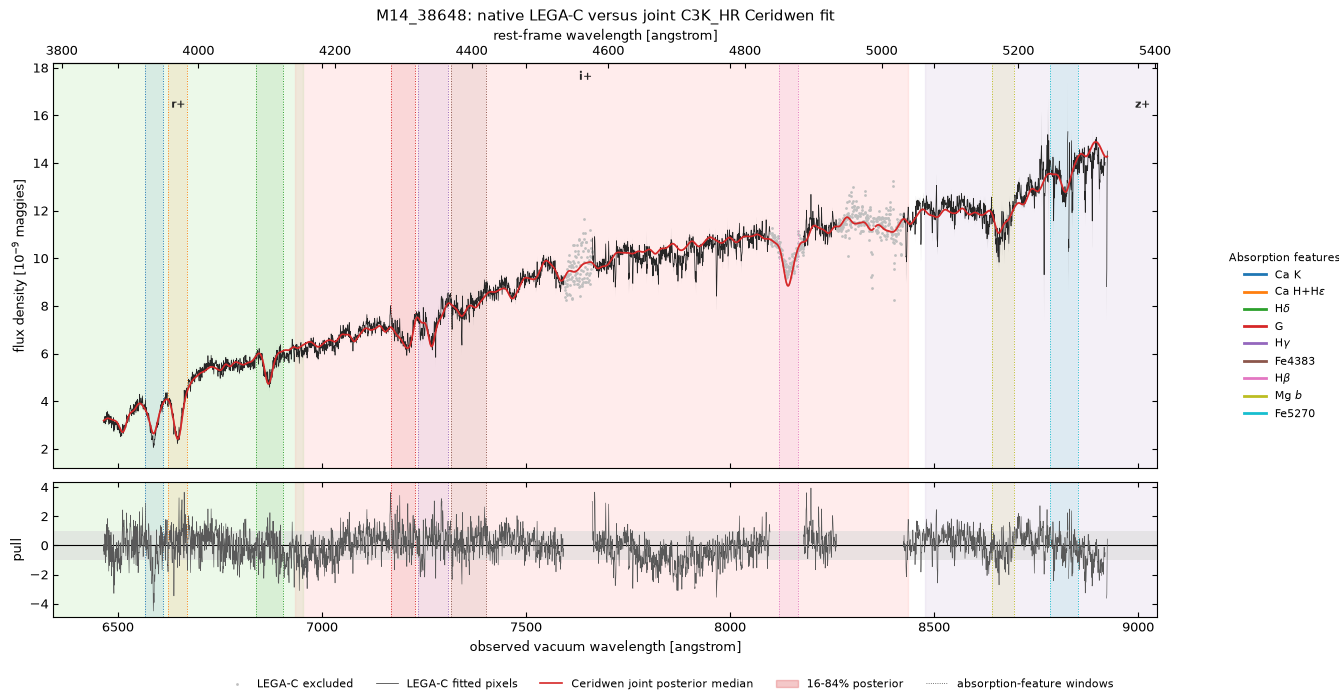

In [8]:
native_effective_uncertainty = np.hypot(spectrum_uncertainty, calibration_fraction * np.abs(spec_q50))
native_excluded_mask = native_valid & ~spectrum_mask
native_plot_scale = 1e9 / CGS_FNU_PER_MAGGIE
native_fitted_flux = np.where(spectrum_mask, spectrum_flux, np.nan)
native_fitted_uncertainty = np.where(spectrum_mask, spectrum_uncertainty, np.nan)
native_plot_pull = np.where(
    spectrum_mask, (spectrum_flux - spec_q50) / native_effective_uncertainty, np.nan
)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), gridspec_kw={"height_ratios": [3, 1]}, sharex=True)
axes[0].scatter(
    wave_vacuum[native_excluded_mask],
    spectrum_flux[native_excluded_mask] * native_plot_scale,
    s=4, color="0.75", linewidths=0, label="LEGA-C excluded", rasterized=True,
)
axes[0].fill_between(
    wave_vacuum,
    (native_fitted_flux - native_fitted_uncertainty) * native_plot_scale,
    (native_fitted_flux + native_fitted_uncertainty) * native_plot_scale,
    color="0.5", alpha=0.18, linewidth=0,
)
axes[0].plot(
    wave_vacuum, native_fitted_flux * native_plot_scale, color="0.15", lw=0.5,
    label="LEGA-C fitted pixels", rasterized=True,
)
axes[0].plot(
    wave_vacuum, np.where(native_valid, spec_q50, np.nan) * native_plot_scale, color="tab:red", lw=1.2,
    label="Ceridwen joint posterior median",
)
axes[0].fill_between(
    wave_vacuum,
    np.where(native_valid, spec_q16, np.nan) * native_plot_scale,
    np.where(native_valid, spec_q84, np.nan) * native_plot_scale,
    color="tab:red", alpha=0.25, label="16-84% posterior",
)
axes[0].set(ylabel=r"flux density [$10^{-9}$ maggies]")
axes[0].set_title(f"{TARGET_ID}: native LEGA-C versus joint C3K_HR Ceridwen fit")
axes[0].plot([], [], color="0.3", lw=0.6, linestyle=":", label="absorption-feature windows")
# Below the panels: inside the axes the legend covers the band names.
fig.legend(*axes[0].get_legend_handles_labels(), loc="lower center", frameon=False, ncol=5, fontsize=8)
axes[1].axhspan(-1, 1, color="0.85", alpha=0.55, linewidth=0)
axes[1].axhline(0, color="k", lw=0.8)
axes[1].plot(wave_vacuum, native_plot_pull, color="0.35", lw=0.45, rasterized=True)
axes[1].set_ylabel("pull")
mark_filter_ranges(axes[0])
mark_filter_ranges(axes[1], show_labels=False)
mark_absorption_features(axes[0], z_catalog, show_labels=False)
mark_absorption_features(axes[1], z_catalog, xlabel="observed vacuum wavelength [angstrom]")
secondary_axis = axes[0].secondary_xaxis(
    "top",
    functions=(lambda observed: observed / (1 + z_catalog), lambda rest: rest * (1 + z_catalog)),
)
secondary_axis.set_xlabel("rest-frame wavelength [angstrom]")
spectral_tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

## Calibration polynomial

- Posterior of $P(\lambda)$: median and 16-84 band over the draws; dotted where pixels are masked.
- Full calibration vector is $s_{\mathrm{spectrum}}\,P(\lambda)$.

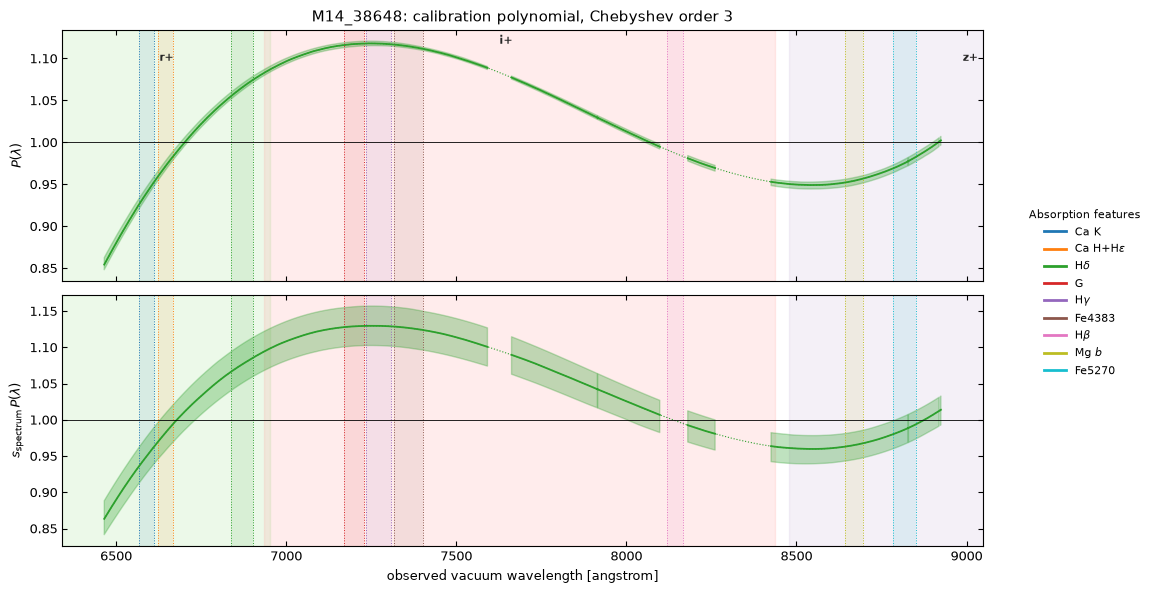

In [9]:
poly_q16, poly_q50, poly_q84 = np.percentile(calibration_vectors, [16, 50, 84], axis=0)
scaling_draws = np.asarray(predictive_batch["spectrum_scaling"]).reshape(-1)
full_q16, full_q50, full_q84 = np.percentile(
    calibration_vectors * scaling_draws[:, None], [16, 50, 84], axis=0
)
fitted_range = (spectrum_wave >= spectrum_wave[spectrum_mask].min()) & (
    spectrum_wave <= spectrum_wave[spectrum_mask].max()
)
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
bands = [
    (poly_q16, poly_q50, poly_q84, r"$P(\lambda)$"),
    (full_q16, full_q50, full_q84, r"$s_{\mathrm{spectrum}}\,P(\lambda)$"),
]
for ax, (q16, q50, q84, label) in zip(axes, bands):
    ax.fill_between(
        spectrum_wave, np.where(spectrum_mask, q16, np.nan), np.where(spectrum_mask, q84, np.nan),
        color="tab:green", alpha=0.3,
    )
    ax.plot(spectrum_wave, np.where(fitted_range, q50, np.nan), color="tab:green", lw=0.8, ls=":")
    ax.plot(spectrum_wave, np.where(spectrum_mask, q50, np.nan), color="tab:green", lw=1.3)
    ax.axhline(1.0, color="k", lw=0.6)
    ax.set_ylabel(label)
axes[0].set_title(
    f"{TARGET_ID}: calibration polynomial, Chebyshev order {SETTINGS['calibration_order']}"
)
mark_filter_ranges(axes[0])
mark_filter_ranges(axes[1], show_labels=False)
mark_absorption_features(axes[0], z_catalog, show_labels=False)
mark_absorption_features(axes[1], z_catalog, xlabel="observed vacuum wavelength [angstrom]")
spectral_tight_layout()
plt.show()

## Corners and SFH

- 400 evenly spaced rows of the equal-weight posterior; [Fe/H] = Z + 1.7328283.
- Formed-mass fractions per SFH bin and the mass-weighted age from the same rows.
- Physical corner; dust parameters against the mass fractions; SFH band.
- Quantile table and derived outputs to `ceridwen_derived_outputs.h5`.

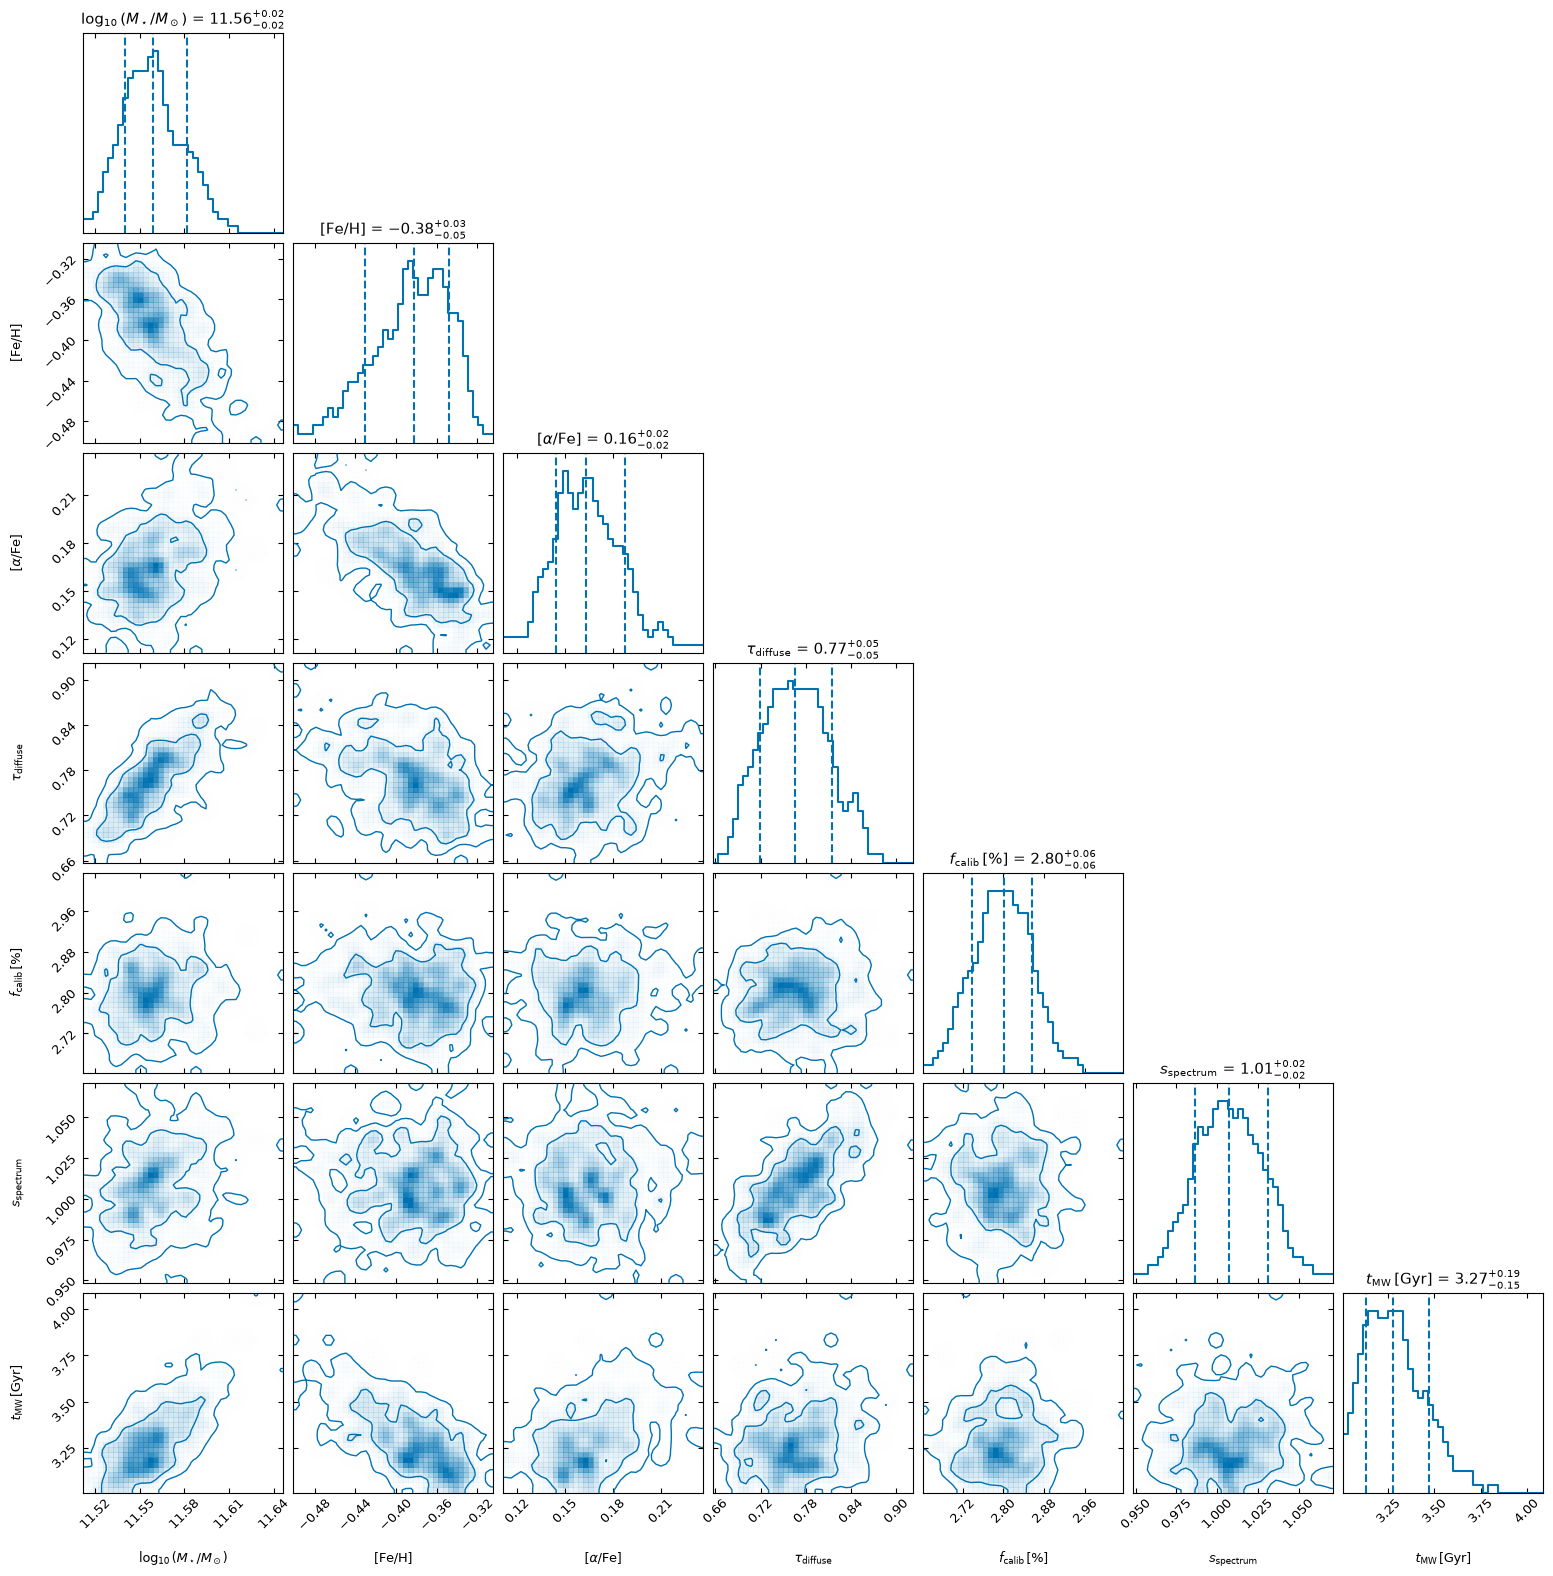

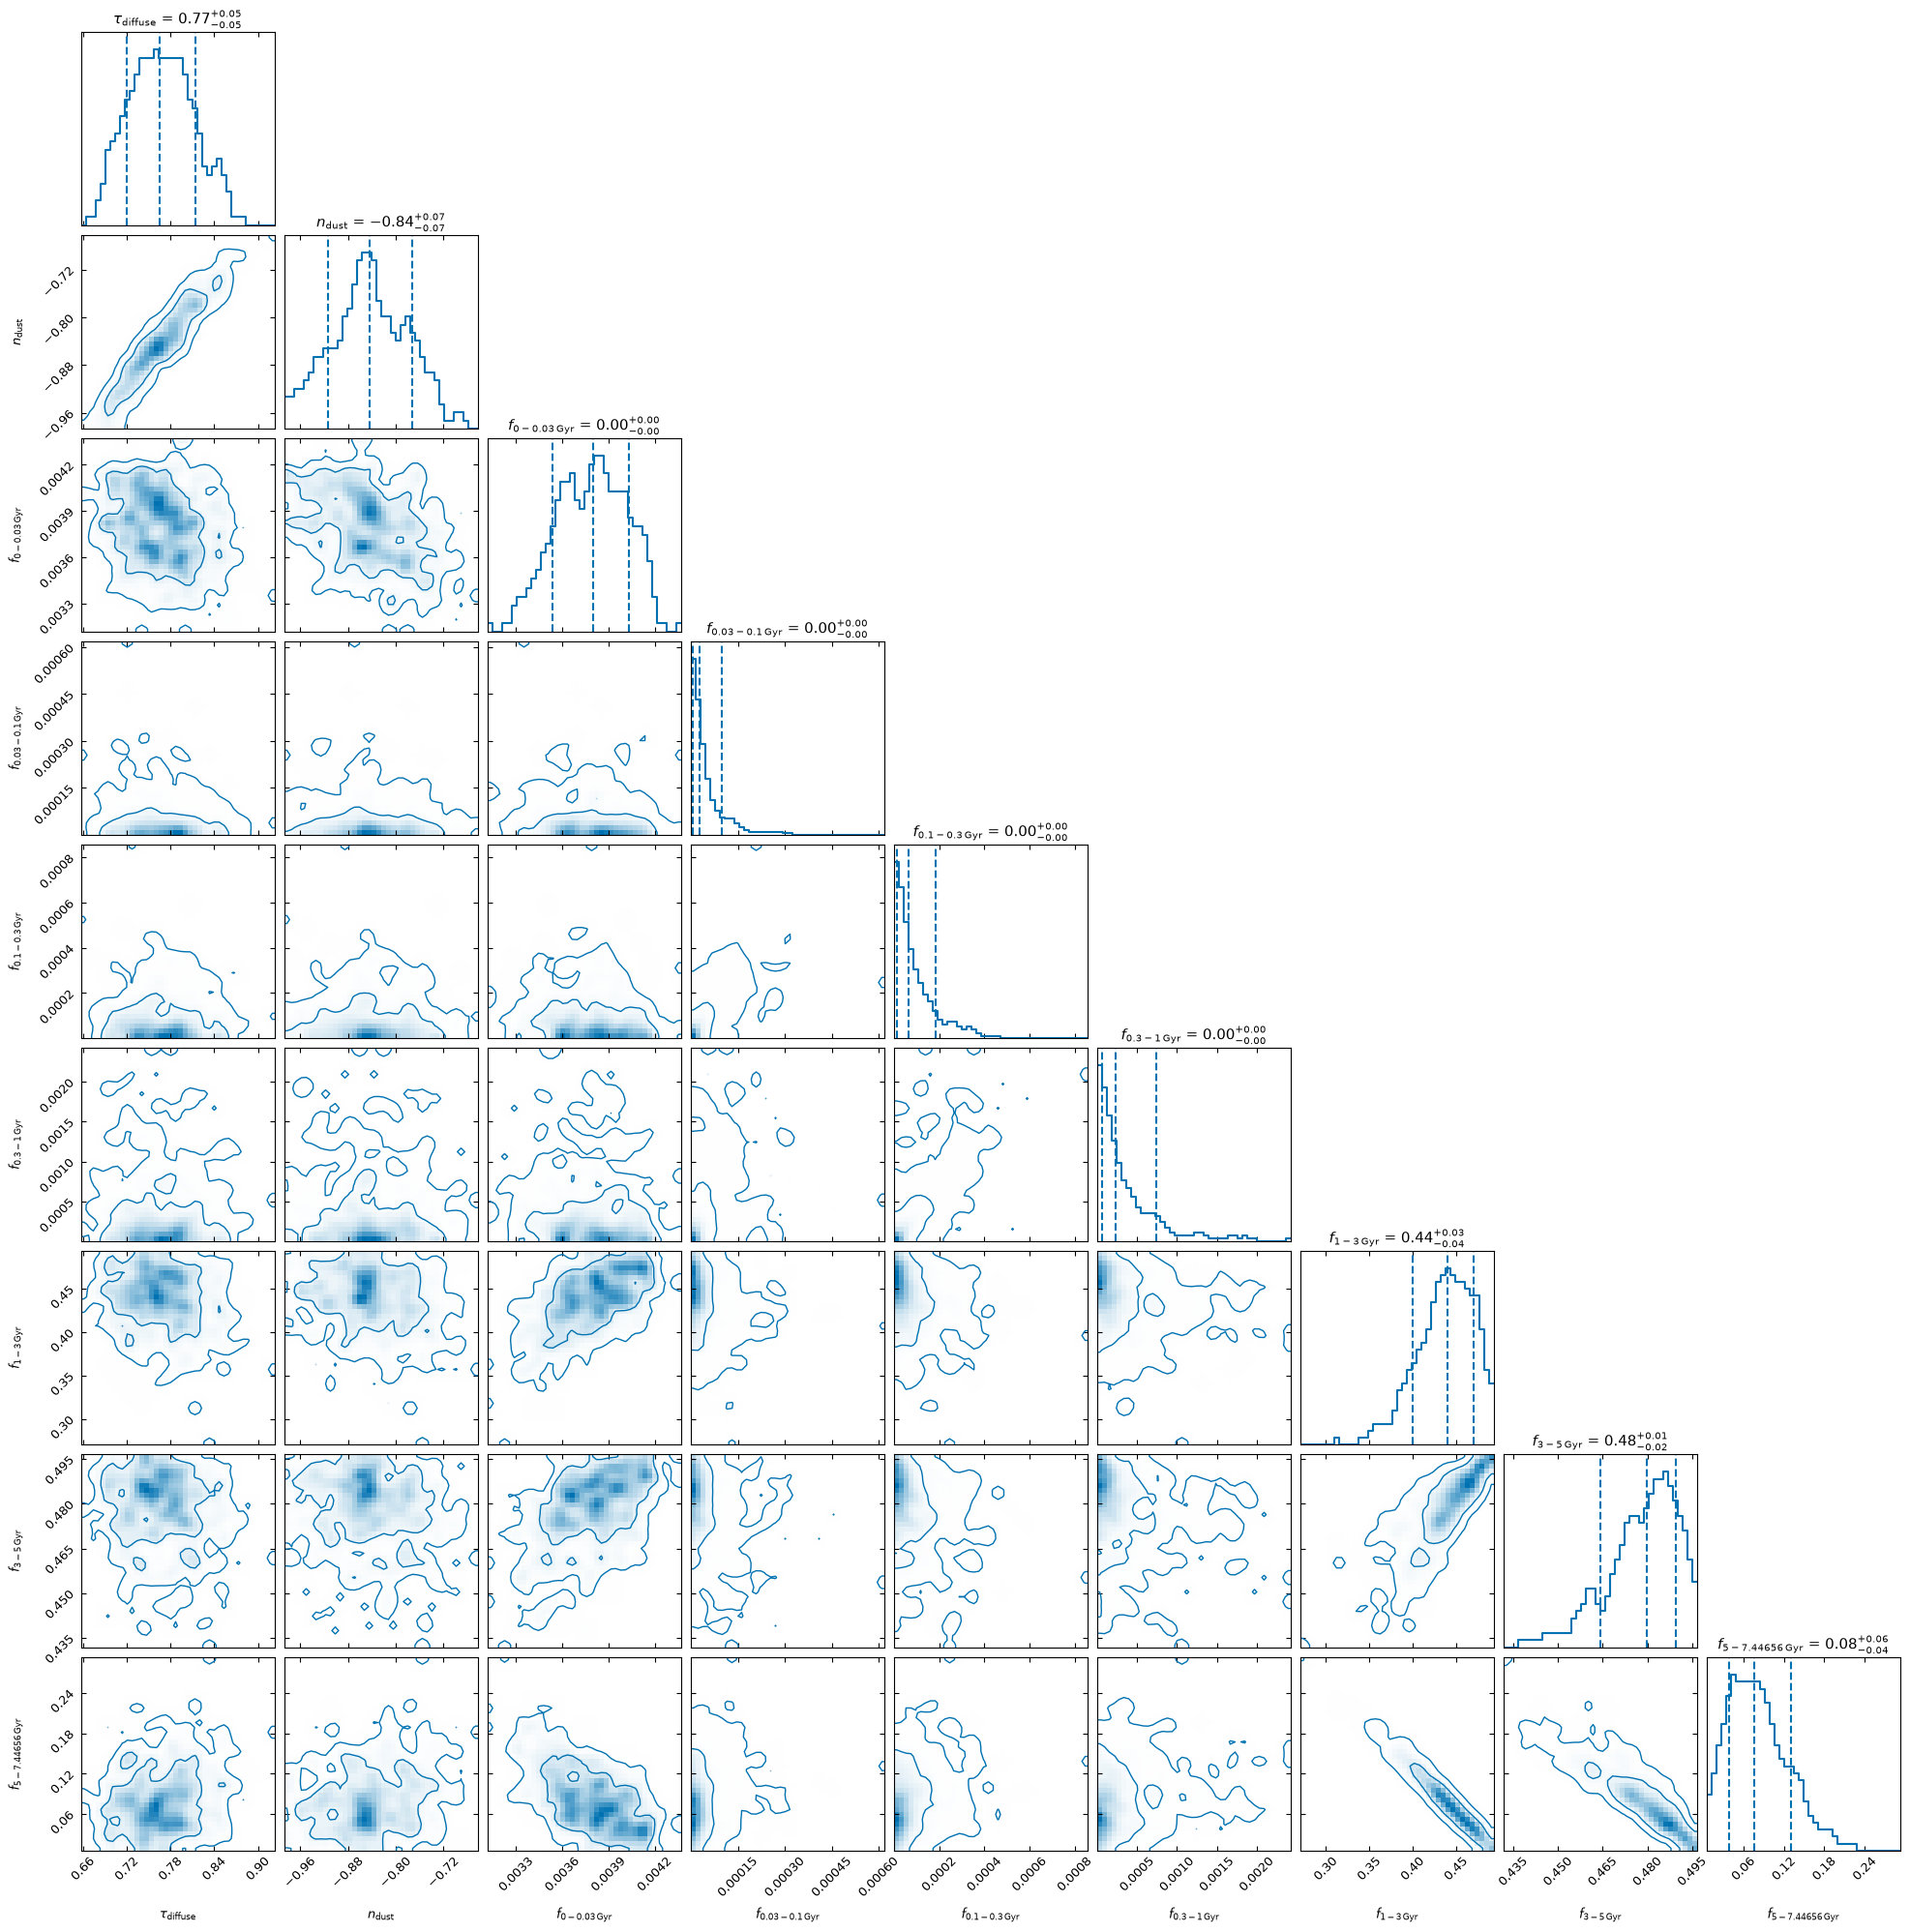

,parameter,q16,q50,q84,unit
0,logsfr_ratios[0],2.144504,2.765773,3.657646,dex
1,logsfr_ratios[1],-0.207085,0.113211,0.493898,dex
2,logsfr_ratios[2],-0.281355,-0.005165,0.347157,dex
3,logsfr_ratios[3],-0.403267,-0.026083,0.270186,dex
4,logsfr_ratios[4],-3.869616,-3.080827,-2.547348,dex
5,logsfr_ratios[5],0.775460,1.059720,1.411673,dex
6,logsfr_ratios[6],-0.023709,0.216496,0.572317,dex
7,logmass,11.539714,11.558569,11.581804,log10(M_sun)
8,[Fe/H],-0.429996,-0.381954,-0.347635,dex
9,afe,0.144507,0.163380,0.187737,dex


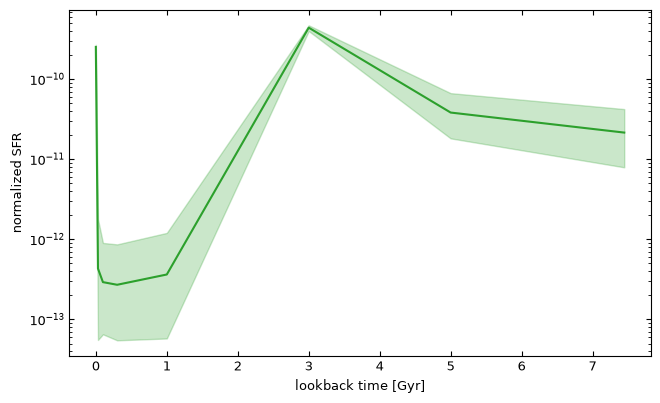

In [10]:
posterior_indices = np.linspace(0, len(joint_posterior["logmass"]) - 1, 400, dtype=int)
selected_posterior = {name: np.asarray(values)[posterior_indices] for name, values in joint_posterior.items()}


def scalar_draws(name):
    return np.asarray(selected_posterior[name]).reshape(len(posterior_indices))


joint_histories = np.asarray(
    [
        logsfr_ratios_to_sfh(ratios, sfh_times_yr=lookback_template * 1e9)
        for ratios in selected_posterior["logsfr_ratios"]
    ]
)
interval_masses = 0.5 * (joint_histories[:, :-1] + joint_histories[:, 1:]) * np.diff(lookback_template) * 1e9
joint_mass_fractions = interval_masses / interval_masses.sum(axis=1)[:, None]
joint_ages = (joint_mass_fractions * 0.5 * (lookback_template[:-1] + lookback_template[1:])).sum(axis=1)

# Grid Z is log10 of the iron abundance relative to Z_sun = 0.0185
# (ceridwen/scripts_afe/build_afe_hr_grid.py), so [Fe/H] = Z + FEH_OFFSET.
FEH_OFFSET = 1.7328283
calibration_percent = 100.0 * np.exp(scalar_draws("log_f_calib"))
mass_fraction_labels = [
    rf"$f_{{{start:g}-{stop:g}\,\mathrm{{Gyr}}}}$" for start, stop in pairwise(lookback_template)
]
CORNER_STYLE = {
    "bins": 40,
    "color": "#0072B2",
    "smooth": 1.2,
    "smooth1d": 1.0,
    "plot_datapoints": False,
    "plot_density": True,
    "plot_contours": True,
    "fill_contours": False,
    "hist_kwargs": {"linewidth": 1.5},
    "contour_kwargs": {"linewidths": 1.0},
    "quantiles": [0.16, 0.50, 0.84],
    "title_quantiles": [0.16, 0.50, 0.84],
    "show_titles": True,
    "levels": (0.68, 0.95),
}

physical = [  # (label, draws, range)
    (r"$\log_{10}(M_\star/M_\odot)$", scalar_draws("logmass"), joint_bounds["logmass"]),
    (r"$[\mathrm{Fe}/\mathrm{H}]$", scalar_draws("Z") + FEH_OFFSET, tuple(np.asarray(joint_bounds["Z"]) + FEH_OFFSET)),
    (r"$[\alpha/\mathrm{Fe}]$", scalar_draws("afe"), joint_bounds["afe"]),
    (r"$\tau_{\mathrm{diffuse}}$", scalar_draws("diffuse_tau_kc"), joint_bounds["diffuse_tau_kc"]),
    (r"$f_{\mathrm{calib}}\,[\%]$", calibration_percent, tuple(100.0 * np.exp(joint_bounds["log_f_calib"]))),
    (r"$s_{\mathrm{spectrum}}$", scalar_draws("spectrum_scaling"), joint_bounds["spectrum_scaling"]),
]
if "zred" in PRIORS:
    # Redshift as a velocity offset from the catalogue: dv = c (z - z_cat) / (1 + z_cat).
    zred_offset_kms = C_KMS * (scalar_draws("zred") - z_catalog) / (1.0 + z_catalog)
    physical.append(
        (r"$\Delta v_z\,[\mathrm{km\,s^{-1}}]$", zred_offset_kms, tuple(np.percentile(zred_offset_kms, [0.1, 99.9])))
    )
if "sigma_smooth" in PRIORS:
    physical.append(
        (r"$\sigma_\star\,[\mathrm{km\,s^{-1}}]$", scalar_draws("sigma_smooth"), joint_bounds["sigma_smooth"])
    )
physical.append((r"$t_{\mathrm{MW}}\,[\mathrm{Gyr}]$", joint_ages, (0.0, universe_age)))
corner.corner(
    np.column_stack([draws for _, draws, _ in physical]),
    labels=[label for label, _, _ in physical],
    range=[limits for _, _, limits in physical] if QUICK else None,
    **CORNER_STYLE,
)
plt.show()

corner.corner(
    np.column_stack([scalar_draws("diffuse_tau_kc"), scalar_draws("diffuse_dust_index"), joint_mass_fractions]),
    labels=[r"$\tau_{\mathrm{diffuse}}$", r"$n_{\mathrm{dust}}$", *mass_fraction_labels],
    range=(
        [joint_bounds["diffuse_tau_kc"], joint_bounds["diffuse_dust_index"]] + [(0.0, 1.0)] * N_RATIOS
        if QUICK
        else None
    ),
    **CORNER_STYLE,
)
plt.show()

summary_draws = {
    **{f"logsfr_ratios[{i}]": selected_posterior["logsfr_ratios"][:, i] for i in range(N_RATIOS)},
    **{name: scalar_draws(name) for name in ["logmass", "Z", "afe", "diffuse_tau_kc", "log_f_calib"]},
    "calibration floor [%]": calibration_percent,
    "spectrum_scaling": scalar_draws("spectrum_scaling"),
    **{f"calibration a_{n + 1}": calibration_coefficients[:, n] for n in range(SETTINGS["calibration_order"])},
}
if "zred" in PRIORS:
    summary_draws["zred"] = scalar_draws("zred")
    summary_draws["redshift offset [km/s]"] = zred_offset_kms
if "sigma_smooth" in PRIORS:
    summary_draws["sigma_smooth"] = scalar_draws("sigma_smooth")
summary_draws["mass-weighted age [Gyr]"] = joint_ages
summary_units = {
    "logmass": "log10(M_sun)",
    "Z": "log10 iron abundance; [Fe/H] = Z + 1.7328283",
    "afe": "dex",
    "diffuse_tau_kc": "dimensionless",
    "log_f_calib": "natural log fraction",
    "calibration floor [%]": "percent",
    "spectrum_scaling": "dimensionless",
    "zred": "dimensionless",
    "redshift offset [km/s]": "km/s",
    "sigma_smooth": "km/s",
    "mass-weighted age [Gyr]": "Gyr",
}
summary = pd.DataFrame(
    [
        {
            "parameter": name,
            **dict(zip(["q16", "q50", "q84"], np.percentile(draws, [16, 50, 84]))),
            "unit": "dex" if name.startswith("logsfr_ratios")
            else "dimensionless" if name.startswith("calibration a_")
            else summary_units[name],
        }
        for name, draws in summary_draws.items()
    ]
)
summary_display = summary.copy()
z_row = summary_display["parameter"] == "Z"
summary_display.loc[z_row, ["q16", "q50", "q84"]] += FEH_OFFSET
summary_display.loc[z_row, ["parameter", "unit"]] = ["[Fe/H]", "dex"]
display(summary_display)

sfh_q16, sfh_q50, sfh_q84 = np.percentile(joint_histories, [16, 50, 84], axis=0)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(lookback_template, sfh_q50, color="tab:green")
ax.fill_between(lookback_template, sfh_q16, sfh_q84, color="tab:green", alpha=0.25)
ax.set(yscale="log", xlabel="lookback time [Gyr]", ylabel="normalized SFR")
plt.show()

with h5py.File(RESULT_DIR / "ceridwen_derived_outputs.h5", "w") as derived_file:
    string_dtype = h5py.string_dtype(encoding="utf-8")
    derived_file.attrs.update(
        {
            "fit_mode": "full_spectrum",
            "target_id": TARGET_ID,
            "object_id": OBJECT_ID,
            "manifest_index": MANIFEST_INDEX,
            "redshift": z_catalog,
            "sigma_star_kms": sigma_star,
            "zred_half_width": SETTINGS["zred_half_width"] if "zred" in PRIORS else 0.0,
            "sigma_star_err": sigma_star_err,
            "catalogue_sn": float(galaxy["SN"]),
            "has_4000a_coverage": has_4000a_coverage,
            "random_seed": SEED,
            "parameter_block": model_parameter_block_text,
            "photometry_source": SETTINGS["photometry"],
            "calibration_order": SETTINGS["calibration_order"],
            "wall_time_s": joint_result.wall_time_s,
            "n_likelihood_calls": joint_result.n_likelihood_calls,
            **joint_settings,
        }
    )
    summary_group = derived_file.create_group("summary")
    for column in ["parameter", "unit"]:
        summary_group.create_dataset(
            column, data=np.asarray(summary[column], dtype=object), dtype=string_dtype
        )
    for column in ["q16", "q50", "q84"]:
        summary_group.create_dataset(column, data=summary[column].to_numpy())

    sfh_group = derived_file.create_group("sfh")
    sfh_group.create_dataset("lookback_time_gyr", data=lookback_template)
    sfh_group.create_dataset("normalized_sfr_draws", data=joint_histories)
    sfh_group.create_dataset("normalized_sfr_q16", data=sfh_q16)
    sfh_group.create_dataset("normalized_sfr_q50", data=sfh_q50)
    sfh_group.create_dataset("normalized_sfr_q84", data=sfh_q84)
    sfh_group.create_dataset("mass_fraction_draws", data=joint_mass_fractions)
    for column, values in zip(["q16", "q50", "q84"], np.percentile(joint_mass_fractions, [16, 50, 84], axis=0)):
        sfh_group.create_dataset(f"mass_fraction_{column}", data=values)
    sfh_group.create_dataset("mass_weighted_age_gyr", data=joint_ages)

    diagnostics_group = derived_file.create_group("diagnostics")
    diagnostics_group.attrs.update(
        {
            "log_evidence": joint_result.log_evidence,
            "log_evidence_err": joint_result.log_evidence_err,
            "posterior_weight_ess": joint_weight_ess,
            "status": joint_status,
            "passed": joint_diagnostics_passed,
            "photometry_chi2": phot_chi2,
            "spectrum_chi2": spectrum_chi2,
            "joint_chi2": joint_chi2,
            "photometry_ndof": phot_obs.ndof,
            "spectrum_ndof": spectrum_obs.ndof,
            "joint_ndof": joint_points,
        }
    )

    photometry_group = derived_file.create_group("photometry")
    photometry_group.create_dataset("filters", data=np.asarray(FILTER_NAMES, dtype=object), dtype=string_dtype)
    photometry_group.create_dataset("wavelength", data=filter_wave_eff)
    photometry_group.create_dataset("observed", data=phot_flux)
    photometry_group.create_dataset("uncertainty", data=phot_uncertainty)
    photometry_group.create_dataset("mask", data=phot_fit_mask)
    photometry_group.create_dataset("posterior_q16", data=phot_q16)
    photometry_group.create_dataset("posterior_q50", data=phot_q50)
    photometry_group.create_dataset("posterior_q84", data=phot_q84)
    photometry_group.create_dataset("pull", data=(phot_flux - phot_q50) / phot_uncertainty)

    spectrum_group = derived_file.create_group("spectrum")
    spectrum_group.create_dataset("wavelength", data=spectrum_wave)
    spectrum_group.create_dataset("observed", data=spectrum_flux)
    spectrum_group.create_dataset("uncertainty", data=spectrum_uncertainty)
    spectrum_group.create_dataset("effective_uncertainty", data=effective_spec_uncertainty)
    spectrum_group.create_dataset("mask", data=spectrum_mask)
    spectrum_group.create_dataset("posterior_q16", data=spec_q16)
    spectrum_group.create_dataset("posterior_q50", data=spec_q50)
    spectrum_group.create_dataset("posterior_q84", data=spec_q84)
    spectrum_group.create_dataset("pull", data=spectrum_plot_pull)

    calibration_group = derived_file.create_group("calibration")
    calibration_group.attrs.update(
        {
            "order": SETTINGS["calibration_order"],
            "fit_constant": False,
            "prior_sigma": SETTINGS["calibration_prior_sigma"],
            "marginalized": True,
            "basis": "P(x) = 1 + sum_n a_n T_n(x), Chebyshev, x in [-1, 1] over fitted pixels",
        }
    )
    calibration_group.create_dataset("x", data=np.asarray(calibration_polynomial.x))
    calibration_group.create_dataset("coefficient_draws", data=calibration_coefficients)
    calibration_group.create_dataset("spectrum_scaling_draws", data=scaling_draws)
    calibration_group.create_dataset("polynomial_q16", data=poly_q16)
    calibration_group.create_dataset("polynomial_q50", data=poly_q50)
    calibration_group.create_dataset("polynomial_q84", data=poly_q84)